# Compare ChenDixon 5a 5b
include files: energies_functional_basis.csv

### initialize

In [2]:
import pandas as pd
from pathlib import Path
import shutil
import numpy as np

from ase.io import read
from ase.neighborlist import neighbor_list
from rmsd_min import find_rmsd_min
from export_mlopt_xyz_to_total import cp_mlopt_to_total
from universal import *

from matplotlib import pyplot as plt

In [31]:
df_dft = pd.read_csv("energies_functional_basis.csv")
df_dft.loc[:, 'dE au'] = df_dft.loc[:, '5b au'] - df_dft.loc[:, '5a au']
df_dft.loc[:, 'dE eV'] = df_dft.loc[:, 'dE au'] * hartree_to_eV
df_dft

,Method,Basis,Dispersion,original0/optimized1,5a au,5b au,dE au,dE eV
0,article,article,0,01,-5000.191792,-5000.191502,0.000290,0.007891
1,b3lyp,dgdzvp2,0,0,-5000.191951,-5000.191543,0.000408,0.011105
2,b3lyp,def2svp,1,0,-4999.513907,-4999.527343,-0.013436,-0.365616
3,pbe0,dgdzvp2,1,0,-4998.276882,-4998.278460,-0.001578,-0.042947
4,pbe0,dgdzvp2,1,1,-4998.278606,-4998.280510,-0.001904,-0.051809
5,pbe0,def2svp,1,0,-4997.605881,-4997.615804,-0.009924,-0.270039
6,pbe0,def2svp,1,1,-4997.617272,-4997.628051,-0.010779,-0.293325
7,pbe0,def2svp,0,0,-4997.576561,-4997.583817,-0.007256,-0.197455
8,pbe0,def2tzvp,1,pbe0svp,-4999.058998,-4999.063063,-0.004065,-0.110618
9,pbe0,def2tzvp,1,0,-4999.054146,-4999.057686,-0.003540,-0.096325


In [32]:
df_ml = pd.read_csv("energies_ml.csv")
df_ml.loc[:, 'dE eV'] = df_ml.loc[:, '5b eV'] - df_ml.loc[:, '5a eV']
df_ml

,Method,original0/optimized1,5a eV,5b eV,dE eV
0,matpes_pbe,0,-125.119095,-125.103493,0.015602
1,matpes_pbe,1,-125.164551,-125.135315,0.029236
2,omol25_low,0,-136066.781250,-136066.953125,-0.171875
3,omol25_low,1,-136066.906250,-136067.093750,-0.187500
4,mpa,0,-125.446930,-125.427109,0.019821
5,mpa,1,-125.493195,-125.462975,0.030220
6,matpes_r2scan,0,-162.482773,-162.564026,-0.081253
7,matpes_r2scan,1,-162.538055,-162.602905,-0.064850


### Optimized structure energy

In [33]:
target_structures = ['1', '01']
df_dft_opt = df_dft[df_dft['original0/optimized1'].isin(target_structures)].copy()
df_dft_opt = df_dft_opt.iloc[:, [0,1,4,5,7]]
df_dft_opt

,Method,Basis,5a au,5b au,dE eV
0,article,article,-5000.191792,-5000.191502,0.007891
4,pbe0,dgdzvp2,-4998.278606,-4998.280510,-0.051809
6,pbe0,def2svp,-4997.617272,-4997.628051,-0.293325
10,pbe0,def2tzvp,-4999.060280,-4999.064222,-0.107268
12,pbe,def2svp,-4997.691722,-4997.699375,-0.208249
16,pbe,def2tzvp,-4999.131012,-4999.133300,-0.062267


In [34]:
target_structures1 = [1]
df_ml_opt = df_ml[df_ml['original0/optimized1'].isin(target_structures1)].copy()
df_ml_opt

,Method,original0/optimized1,5a eV,5b eV,dE eV
1,matpes_pbe,1,-125.164551,-125.135315,0.029236
3,omol25_low,1,-136066.906250,-136067.093750,-0.187500
5,mpa,1,-125.493195,-125.462975,0.030220
7,matpes_r2scan,1,-162.538055,-162.602905,-0.064850


###### Combine two df

In [35]:
df_dft_opt_format = df_dft_opt.iloc[:, [0,1,-1]]
df_dft_opt_format.loc[:, 'Method'] = df_dft_opt_format.loc[:, 'Method'] + '_' + df_dft_opt_format.loc[:, 'Basis']
df_dft_opt_format = df_dft_opt_format.drop(columns=['Basis'])
df_dft_opt_format

,Method,dE eV
0,article_article,0.007891
4,pbe0_dgdzvp2,-0.051809
6,pbe0_def2svp,-0.293325
10,pbe0_def2tzvp,-0.107268
12,pbe_def2svp,-0.208249
16,pbe_def2tzvp,-0.062267


In [36]:
df_ml_opt_format = df_ml_opt.iloc[:, [0,-1]]
df_ml_opt_format

,Method,dE eV
1,matpes_pbe,0.029236
3,omol25_low,-0.187500
5,mpa,0.030220
7,matpes_r2scan,-0.064850


In [37]:
df_E_merge = pd.concat([df_dft_opt_format, df_ml_opt_format], axis=0, ignore_index=True)
name_list = df_E_merge['Method'].to_list()
print(name_list)
df_E_merge_index = df_E_merge.set_index('Method')
df_E_merge_index

['article_article', 'pbe0_dgdzvp2', 'pbe0_def2svp', 'pbe0_def2tzvp', 'pbe_def2svp', 'pbe_def2tzvp', 'matpes_pbe', 'omol25_low', 'mpa', 'matpes_r2scan']


,dE eV
Method,
article_article,0.007891
pbe0_dgdzvp2,-0.051809
pbe0_def2svp,-0.293325
pbe0_def2tzvp,-0.107268
pbe_def2svp,-0.208249
pbe_def2tzvp,-0.062267
matpes_pbe,0.029236
omol25_low,-0.187500
mpa,0.030220


###### Energy Deviaion Matrix: Distance between methods

In [38]:
# Matrix construction
df_E_matrix = pd.DataFrame(index=name_list, columns=name_list)

for i in range(len(name_list)):
    for ii in range(i,len(name_list)):
        name_i, name_ii = name_list[i], name_list[ii]
        dE_i = df_E_merge_index.loc[name_i, 'dE eV']
        dE_ii = df_E_merge_index.loc[name_ii, 'dE eV']
        d_dE = abs(dE_ii - dE_i)
        df_E_matrix.loc[name_i, name_ii] = d_dE

df_E_matrix

,article_article,pbe0_dgdzvp2,pbe0_def2svp,pbe0_def2tzvp,pbe_def2svp,pbe_def2tzvp,matpes_pbe,omol25_low,mpa,matpes_r2scan
article_article,0.0,0.059701,0.301216,0.115159,0.21614,0.070158,0.021345,0.195391,0.022329,0.072741
pbe0_dgdzvp2,NaN,0.0,0.241516,0.055458,0.156439,0.010458,0.081045,0.135691,0.082029,0.01304
pbe0_def2svp,NaN,NaN,0.0,0.186057,0.085076,0.231058,0.322561,0.105825,0.323545,0.228475
pbe0_def2tzvp,NaN,NaN,NaN,0.0,0.100981,0.045001,0.136504,0.080232,0.137488,0.042418
pbe_def2svp,NaN,NaN,NaN,NaN,0.0,0.145982,0.237485,0.020749,0.238469,0.143399
pbe_def2tzvp,NaN,NaN,NaN,NaN,NaN,0.0,0.091503,0.125233,0.092487,0.002583
matpes_pbe,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.216736,0.000984,0.094086
omol25_low,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.21772,0.12265
mpa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.09507
matpes_r2scan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [39]:
# Symmetrize: flip top-right to down-left
def symmetrize_matrix(df):
    size_df = len(df)
    for i in range(size_df):
        for ii in range(i,size_df):
            df.iloc[ii, i] = df.iloc[i, ii]
    return df

df_E_matrix = symmetrize_matrix(df_E_matrix)
df_E_matrix


,article_article,pbe0_dgdzvp2,pbe0_def2svp,pbe0_def2tzvp,pbe_def2svp,pbe_def2tzvp,matpes_pbe,omol25_low,mpa,matpes_r2scan
article_article,0.0,0.059701,0.301216,0.115159,0.21614,0.070158,0.021345,0.195391,0.022329,0.072741
pbe0_dgdzvp2,0.059701,0.0,0.241516,0.055458,0.156439,0.010458,0.081045,0.135691,0.082029,0.01304
pbe0_def2svp,0.301216,0.241516,0.0,0.186057,0.085076,0.231058,0.322561,0.105825,0.323545,0.228475
pbe0_def2tzvp,0.115159,0.055458,0.186057,0.0,0.100981,0.045001,0.136504,0.080232,0.137488,0.042418
pbe_def2svp,0.21614,0.156439,0.085076,0.100981,0.0,0.145982,0.237485,0.020749,0.238469,0.143399
pbe_def2tzvp,0.070158,0.010458,0.231058,0.045001,0.145982,0.0,0.091503,0.125233,0.092487,0.002583
matpes_pbe,0.021345,0.081045,0.322561,0.136504,0.237485,0.091503,0.0,0.216736,0.000984,0.094086
omol25_low,0.195391,0.135691,0.105825,0.080232,0.020749,0.125233,0.216736,0.0,0.21772,0.12265
mpa,0.022329,0.082029,0.323545,0.137488,0.238469,0.092487,0.000984,0.21772,0.0,0.09507
matpes_r2scan,0.072741,0.01304,0.228475,0.042418,0.143399,0.002583,0.094086,0.12265,0.09507,0.0


### RMSD matrix
measure distances between opt structures for all

###### copy files to opt_structures_total/

In [40]:
tempxxx = mlopt_to_total(5)
save_folder = Path('opt_structures_total')

###### Calculate RMSD

In [41]:
def read_xyz(abx, namex):
    atoms_name = abx + '_' + namex + '.xyz'
    atoms_path = save_folder / atoms_name
    atomsx = read(atoms_path)
    return atomsx

df_5a_rmsd_matrix = pd.DataFrame(index=name_list, columns=name_list)
df_5b_rmsd_matrix = pd.DataFrame(index=name_list, columns=name_list)
list_df_rmsd_matrix = [df_5a_rmsd_matrix, df_5b_rmsd_matrix]

for ni in range(2):
    abi = ['5a', '5b'][ni]
    df_rmsd_matrixi = list_df_rmsd_matrix[ni]
    for i in range(len(name_list)):
        for ii in range(i,len(name_list)):
            name_i, name_ii = name_list[i], name_list[ii]
            atoms_i, atoms_ii = read_xyz(abi, name_i), read_xyz(abi, name_ii)
            roti, bi, rmsd_mini = find_rmsd_min(atoms_i, atoms_ii)
            df_rmsd_matrixi.loc[name_i, name_ii] = rmsd_mini
    df_rmsd_matrixi = symmetrize_matrix(df_rmsd_matrixi)

df_5a_rmsd_matrix

RMSD (Å): 1.3717264871928113e-16
RMSD (Å): 0.02861222633031591
RMSD (Å): 0.055862435130742766
RMSD (Å): 0.047984656368289094
RMSD (Å): 0.04178555829865872
RMSD (Å): 0.03422267427336449
RMSD (Å): 0.06704485718231105
RMSD (Å): 0.08238738464505514
RMSD (Å): 0.0611940268159344
RMSD (Å): 0.07667777468287502
RMSD (Å): 1.4592592456147896e-16
RMSD (Å): 0.033269169410366985
RMSD (Å): 0.02080966777558937
RMSD (Å): 0.025353803690358084
RMSD (Å): 0.020158580017739944
RMSD (Å): 0.05995516910019841
RMSD (Å): 0.06425513939263874
RMSD (Å): 0.05152587696778762
RMSD (Å): 0.06279476370198735
RMSD (Å): 4.455367634409208e-17
RMSD (Å): 0.024134498828079977
RMSD (Å): 0.024675401745293993
RMSD (Å): 0.04086153948488173
RMSD (Å): 0.0789336156016124
RMSD (Å): 0.06592643975655987
RMSD (Å): 0.07108339650530875
RMSD (Å): 0.0747381014850634
RMSD (Å): 1.4583203353719654e-14
RMSD (Å): 0.027401349874817457
RMSD (Å): 0.02684431593221849
RMSD (Å): 0.05960904010867088
RMSD (Å): 0.052283979831376406
RMSD (Å): 0.05110601588

,article_article,pbe0_dgdzvp2,pbe0_def2svp,pbe0_def2tzvp,pbe_def2svp,pbe_def2tzvp,matpes_pbe,omol25_low,mpa,matpes_r2scan
article_article,0.0,0.028612,0.055862,0.047985,0.041786,0.034223,0.067045,0.082387,0.061194,0.076678
pbe0_dgdzvp2,0.028612,0.0,0.033269,0.02081,0.025354,0.020159,0.059955,0.064255,0.051526,0.062795
pbe0_def2svp,0.055862,0.033269,0.0,0.024134,0.024675,0.040862,0.078934,0.065926,0.071083,0.074738
pbe0_def2tzvp,0.047985,0.02081,0.024134,0.0,0.027401,0.026844,0.059609,0.052284,0.051106,0.056005
pbe_def2svp,0.041786,0.025354,0.024675,0.027401,0.0,0.022912,0.066123,0.062485,0.058383,0.067238
pbe_def2tzvp,0.034223,0.020159,0.040862,0.026844,0.022912,0.0,0.047154,0.054284,0.038933,0.052068
matpes_pbe,0.067045,0.059955,0.078934,0.059609,0.066123,0.047154,0.0,0.040091,0.011132,0.021314
omol25_low,0.082387,0.064255,0.065926,0.052284,0.062485,0.054284,0.040091,0.0,0.039472,0.023762
mpa,0.061194,0.051526,0.071083,0.051106,0.058383,0.038933,0.011132,0.039472,0.0,0.022596
matpes_r2scan,0.076678,0.062795,0.074738,0.056005,0.067238,0.052068,0.021314,0.023762,0.022596,0.0


In [42]:
df_5b_rmsd_matrix

,article_article,pbe0_dgdzvp2,pbe0_def2svp,pbe0_def2tzvp,pbe_def2svp,pbe_def2tzvp,matpes_pbe,omol25_low,mpa,matpes_r2scan
article_article,0.0,0.061754,0.083627,0.069865,0.069247,0.057738,0.01686,0.11285,0.018271,0.049992
pbe0_dgdzvp2,0.061754,0.0,0.028269,0.019232,0.010577,0.022205,0.06107,0.05381,0.05936,0.025149
pbe0_def2svp,0.083627,0.028269,0.0,0.021216,0.025131,0.044538,0.084292,0.045787,0.0824,0.047113
pbe0_def2tzvp,0.069865,0.019232,0.021216,0.0,0.016452,0.026303,0.069479,0.049261,0.068169,0.030588
pbe_def2svp,0.069247,0.010577,0.025131,0.016452,0.0,0.022119,0.068487,0.047192,0.066916,0.03023
pbe_def2tzvp,0.057738,0.022205,0.044538,0.026303,0.022119,0.0,0.055316,0.058857,0.054733,0.019727
matpes_pbe,0.01686,0.06107,0.084292,0.069479,0.068487,0.055316,0.0,0.109565,0.006558,0.044645
omol25_low,0.11285,0.05381,0.045787,0.049261,0.047192,0.058857,0.109565,0.0,0.108569,0.065913
mpa,0.018271,0.05936,0.0824,0.068169,0.066916,0.054733,0.006558,0.108569,0.0,0.044366
matpes_r2scan,0.049992,0.025149,0.047113,0.030588,0.03023,0.019727,0.044645,0.065913,0.044366,0.0


### Find correlation between ddE and RMSD

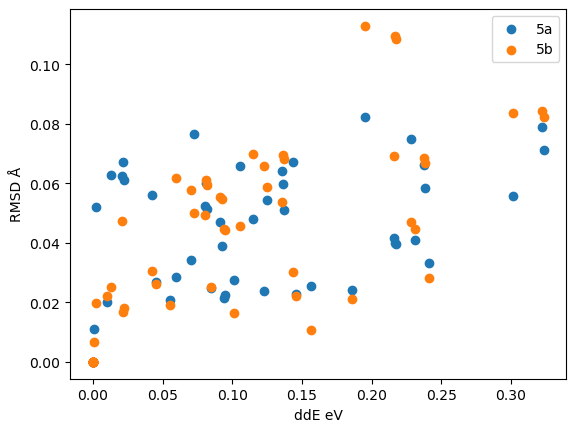

In [43]:
# create lists of dE, rmsd_5a, rmsd_5b
d_name_list = []
d_dE_list = []
d_rmsda_list = []
d_rmsdb_list = []

for i in range(len(name_list)):
    for ii in range(i,len(name_list)):
        name_i, name_ii = name_list[i], name_list[ii]
        d_name_list.append(f"{name_i}_{name_ii}")

        d_dE = df_E_matrix.loc[name_i, name_ii]
        d_dE_list.append(d_dE)

        d_rmsda = df_5a_rmsd_matrix.loc[name_i, name_ii]
        d_rmsdb = df_5b_rmsd_matrix.loc[name_i, name_ii]
        d_rmsda_list.append(d_rmsda)
        d_rmsdb_list.append(d_rmsdb)


fig, ax = plt.subplots()
ax.scatter(d_dE_list, d_rmsda_list, label='5a')
ax.scatter(d_dE_list, d_rmsdb_list, label='5b')

ax.legend()
ax.set_xlabel('ddE eV')
ax.set_ylabel('RMSD Å')

plt.show()




### Results

In [44]:
df_E_merge_index

,dE eV
Method,
article_article,0.007891
pbe0_dgdzvp2,-0.051809
pbe0_def2svp,-0.293325
pbe0_def2tzvp,-0.107268
pbe_def2svp,-0.208249
pbe_def2tzvp,-0.062267
matpes_pbe,0.029236
omol25_low,-0.187500
mpa,0.030220


In [45]:
df_E_matrix

,article_article,pbe0_dgdzvp2,pbe0_def2svp,pbe0_def2tzvp,pbe_def2svp,pbe_def2tzvp,matpes_pbe,omol25_low,mpa,matpes_r2scan
article_article,0.0,0.059701,0.301216,0.115159,0.21614,0.070158,0.021345,0.195391,0.022329,0.072741
pbe0_dgdzvp2,0.059701,0.0,0.241516,0.055458,0.156439,0.010458,0.081045,0.135691,0.082029,0.01304
pbe0_def2svp,0.301216,0.241516,0.0,0.186057,0.085076,0.231058,0.322561,0.105825,0.323545,0.228475
pbe0_def2tzvp,0.115159,0.055458,0.186057,0.0,0.100981,0.045001,0.136504,0.080232,0.137488,0.042418
pbe_def2svp,0.21614,0.156439,0.085076,0.100981,0.0,0.145982,0.237485,0.020749,0.238469,0.143399
pbe_def2tzvp,0.070158,0.010458,0.231058,0.045001,0.145982,0.0,0.091503,0.125233,0.092487,0.002583
matpes_pbe,0.021345,0.081045,0.322561,0.136504,0.237485,0.091503,0.0,0.216736,0.000984,0.094086
omol25_low,0.195391,0.135691,0.105825,0.080232,0.020749,0.125233,0.216736,0.0,0.21772,0.12265
mpa,0.022329,0.082029,0.323545,0.137488,0.238469,0.092487,0.000984,0.21772,0.0,0.09507
matpes_r2scan,0.072741,0.01304,0.228475,0.042418,0.143399,0.002583,0.094086,0.12265,0.09507,0.0


from dE: matpes_r2scan, pbe_def2tzvp, pbe0_dgdzvp2 are close to pbe0_def2tzvp

Bond length \~ 2Å \
Gaussian default opt criteria RMS=0.0012 \~ .3f --> consider as the same\
Precision of the cooridinations .6f --> exactly the same

In [46]:
df_5a_rmsd_matrix

,article_article,pbe0_dgdzvp2,pbe0_def2svp,pbe0_def2tzvp,pbe_def2svp,pbe_def2tzvp,matpes_pbe,omol25_low,mpa,matpes_r2scan
article_article,0.0,0.028612,0.055862,0.047985,0.041786,0.034223,0.067045,0.082387,0.061194,0.076678
pbe0_dgdzvp2,0.028612,0.0,0.033269,0.02081,0.025354,0.020159,0.059955,0.064255,0.051526,0.062795
pbe0_def2svp,0.055862,0.033269,0.0,0.024134,0.024675,0.040862,0.078934,0.065926,0.071083,0.074738
pbe0_def2tzvp,0.047985,0.02081,0.024134,0.0,0.027401,0.026844,0.059609,0.052284,0.051106,0.056005
pbe_def2svp,0.041786,0.025354,0.024675,0.027401,0.0,0.022912,0.066123,0.062485,0.058383,0.067238
pbe_def2tzvp,0.034223,0.020159,0.040862,0.026844,0.022912,0.0,0.047154,0.054284,0.038933,0.052068
matpes_pbe,0.067045,0.059955,0.078934,0.059609,0.066123,0.047154,0.0,0.040091,0.011132,0.021314
omol25_low,0.082387,0.064255,0.065926,0.052284,0.062485,0.054284,0.040091,0.0,0.039472,0.023762
mpa,0.061194,0.051526,0.071083,0.051106,0.058383,0.038933,0.011132,0.039472,0.0,0.022596
matpes_r2scan,0.076678,0.062795,0.074738,0.056005,0.067238,0.052068,0.021314,0.023762,0.022596,0.0


from 5a structure:\
5 dft are close to each other (max=0.04, majority~0.02).\
4 ff are close to each other (max=0.04, median=0.02).\
these two sets are far from each other (min\~0.05, max\~0.08).

In [47]:
df_5b_rmsd_matrix

,article_article,pbe0_dgdzvp2,pbe0_def2svp,pbe0_def2tzvp,pbe_def2svp,pbe_def2tzvp,matpes_pbe,omol25_low,mpa,matpes_r2scan
article_article,0.0,0.061754,0.083627,0.069865,0.069247,0.057738,0.01686,0.11285,0.018271,0.049992
pbe0_dgdzvp2,0.061754,0.0,0.028269,0.019232,0.010577,0.022205,0.06107,0.05381,0.05936,0.025149
pbe0_def2svp,0.083627,0.028269,0.0,0.021216,0.025131,0.044538,0.084292,0.045787,0.0824,0.047113
pbe0_def2tzvp,0.069865,0.019232,0.021216,0.0,0.016452,0.026303,0.069479,0.049261,0.068169,0.030588
pbe_def2svp,0.069247,0.010577,0.025131,0.016452,0.0,0.022119,0.068487,0.047192,0.066916,0.03023
pbe_def2tzvp,0.057738,0.022205,0.044538,0.026303,0.022119,0.0,0.055316,0.058857,0.054733,0.019727
matpes_pbe,0.01686,0.06107,0.084292,0.069479,0.068487,0.055316,0.0,0.109565,0.006558,0.044645
omol25_low,0.11285,0.05381,0.045787,0.049261,0.047192,0.058857,0.109565,0.0,0.108569,0.065913
mpa,0.018271,0.05936,0.0824,0.068169,0.066916,0.054733,0.006558,0.108569,0.0,0.044366
matpes_r2scan,0.049992,0.025149,0.047113,0.030588,0.03023,0.019727,0.044645,0.065913,0.044366,0.0


5b: same conclusion as 5a

###### 5a: 2-4 Ti-Ti distance; 5b: 0-7 Ti-Ti distance as reference
0-based index

In [52]:
df_titi_nn_distance = pd.DataFrame(index=name_list, columns=['5a_24','5b_07'])

for i in ['5a', '5b']:
    for j in name_list:
        atoms_path = save_folder / f'{i}_{j}.xyz'
        atoms = read(atoms_path)
        if i == '5a':
            dist_5a24 = atoms.get_distance(2, 4, mic=False)
            df_titi_nn_distance.loc[j, '5a_24'] = dist_5a24
            dist_5a12 = atoms.get_distance(1, 2, mic=False)
            df_titi_nn_distance.loc[j, '5a_12'] = dist_5a12
        elif i == '5b':
            dist_5b07 = atoms.get_distance(0, 7, mic=False)
            df_titi_nn_distance.loc[j, '5b_07'] = dist_5b07
            dist_5b79 = atoms.get_distance(7, 9, mic=False)
            df_titi_nn_distance.loc[j, '5b_79'] = dist_5b79


df_titi_nn_distance

,5a_24,5b_07,5a_12,5b_79
article_article,2.764971,2.889045,1.961589,1.989680
pbe0_dgdzvp2,2.742843,2.869302,1.950372,1.975925
pbe0_def2svp,2.729188,2.843088,1.935482,1.957013
pbe0_def2tzvp,2.729421,2.841325,1.936964,1.959152
pbe_def2svp,2.741549,2.863807,1.956828,1.972027
pbe_def2tzvp,2.745088,2.865971,1.960064,1.975243
matpes_pbe,2.764263,2.88031,1.962863,2.012194
omol25_low,2.744672,2.84879,1.944450,1.968791
mpa,2.758377,2.87718,1.963653,2.009870
matpes_r2scan,2.753483,2.860347,1.948245,1.989180


### Ti-Ti nearest neighbor distance

In [ ]:
def ti_nn_distance(fname):
    atoms = read(fname)  # your filename

    # Get Ti indices only
    symbols = np.array(atoms.get_chemical_symbols())
    ti_idx = np.where(symbols == "Ti")[0]

    # Build neighbor list for Ti–Ti pairs within 5.0 Å (adjust as needed)
    i, j, d = neighbor_list("ijd", atoms, cutoff=5.0, self_interaction=False)

    # print(i)
    # print(j)
    # print(d)

    # Filter to only Ti–Ti pairs
    mask_titi = np.isin(i, ti_idx) & np.isin(j, ti_idx)
    i_titi, j_titi, d_titi = i[mask_titi], j[mask_titi], d[mask_titi]

    # For each Ti, find its nearest Ti neighbor
    nearest = {}
    for k in ti_idx:
        # Pairs where this Ti is i or j
        my_pairs = ((i_titi == k) | (j_titi == k))
        if np.any(my_pairs):
            my_dists = d_titi[my_pairs]
            nearest_neighbor_dist = my_dists.min()
            nearest_neighbor_idx = i_titi[my_pairs][my_dists.argmin()] if i_titi[my_pairs][my_dists.argmin()] != k else j_titi[my_pairs][my_dists.argmin()]
            nearest[k] = (nearest_neighbor_idx, nearest_neighbor_dist)
        else:
            nearest[k] = (None, np.inf)

    # Print table: nearest Ti–Ti distance for each Ti
    print("\nNearest Ti–Ti distances (0-based indices)")
    print("Ti_idx  Nearest_Ti  Dist(Å)")
    for ti, (neighbor, dist) in sorted(nearest.items()):
        print(f"{ti:6d}     {neighbor:9d}  {dist:8.4f}")

    return nearest

folder_path = Path('opt_structures_total')
path_5a = list(folder_path.glob('5a*.xyz'))
path_5b = list(folder_path.glob('5b*.xyz'))

# for fname in path_5a:
#     print(fname)
#     xx = ti_nn_distance(fname)
#     print('-------------------\n\n')

for fname in path_5b:
    print(fname)
    xx = ti_nn_distance(fname)
    print('-------------------\n\n')